In [1]:
# ¿Podemos anticipar el patrón de demanda que completará un día usando solo sus primeras seis horas?

# Los perfiles completos históricos definen la variable objetivo; las seis primeras horas son la única información usada para anticiparla.

import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("../data/demanda_comercial.csv.gz", compression="gzip")
data["Fecha"] = pd.to_datetime(data["Fecha"])
hour_columns = [column for column in data.columns if column.startswith("H")]
data = data.dropna().drop_duplicates().set_index("Fecha").sort_index()
data.head()

,H01,H02,H03,H04,H05,H06,H07,H08,H09,H10,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
Fecha,,,,,,,,,,,,,,,,,,,,,
2017-01-01,6090271.96,5887031.28,5708693.89,5538133.02,5389774.53,5288199.94,4851217.85,4876162.18,5073813.27,5359713.29,...,5745568.87,5647807.40,5609297.84,5690105.56,6761038.26,7077861.59,6979468.90,6695312.12,6289107.72,5794545.98
2017-01-02,5557603.42,5361012.17,5239119.86,5163721.70,5249539.75,5438852.95,5566947.57,6055220.80,6588005.66,6979088.72,...,7610559.73,7584026.97,7421194.49,7317194.26,8182697.67,8482127.69,8251009.75,7836278.95,7221234.85,6660691.64
2017-01-03,6160676.02,5924880.04,5764416.93,5685832.28,5778222.13,5985840.29,6083907.36,6545100.21,7092804.54,7461185.94,...,8148614.93,8117168.00,7930900.03,7783762.28,8653467.38,8835882.88,8562448.23,8095841.79,7443299.51,6840297.15
2017-01-04,6321851.20,6092135.24,5905390.85,5827867.82,5925730.02,6182279.89,6276759.96,6737660.53,7256819.19,7608691.40,...,8164513.51,8132006.92,7962749.39,7841533.59,8700506.07,8860255.66,8611085.76,8147451.75,7471240.82,6838250.32
2017-01-05,6395397.96,6162409.22,6001153.67,5918673.26,6005924.21,6225027.53,6322923.78,6739120.44,7307847.42,7619827.03,...,8144209.65,8136193.07,8022918.36,7927405.07,8718181.89,8832234.87,8579992.47,8063978.64,7406615.66,6829864.57


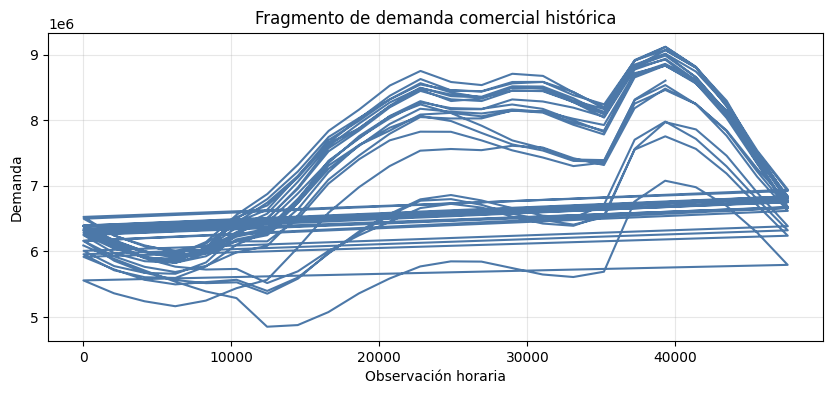

In [2]:
# La serie permite verificar que la demanda cambia a través de días y horas antes de definir perfiles.

series_preview = (
    data.reset_index()
    .melt(id_vars="Fecha", value_vars=hour_columns, var_name="hour", value_name="demand")
    .sort_values(["Fecha", "hour"])
    .head(500)
)

plt.figure(figsize=(10, 4))
plt.plot(series_preview["demand"], color="#4c78a8")
plt.xlabel("Observación horaria")
plt.ylabel("Demanda")
plt.title("Fragmento de demanda comercial histórica")
plt.grid(alpha=0.3)
plt.savefig("../submission/demanda-comercial.png", bbox_inches="tight")
plt.show()

In [3]:
# Se reserva el periodo más reciente para evaluar una predicción sobre días futuros.

cutoff_date = pd.Timestamp("2021-01-01")
train_data = data.loc[data.index < cutoff_date]
test_data = data.loc[data.index >= cutoff_date]

print(f"Días de entrenamiento: {len(train_data)}")
print(f"Días de prueba: {len(test_data)}")

Días de entrenamiento: 1461
Días de prueba: 608


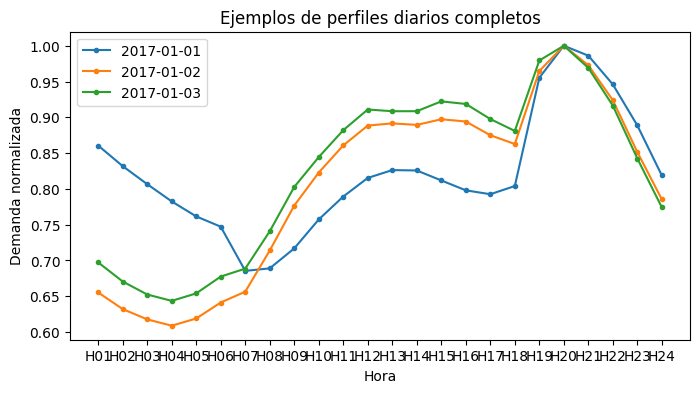

In [4]:
# Los perfiles completos permiten definir patrones históricos; solo se usan para crear la etiqueta y evaluar el pronóstico posterior.

train_profiles = train_data.div(train_data.max(axis=1), axis=0)
test_profiles = test_data.div(test_data.max(axis=1), axis=0)

example_dates = [train_profiles.index[0], train_profiles.index[1], train_profiles.index[2]]
plt.figure(figsize=(8, 4))
for date in example_dates:
    plt.plot(hour_columns, train_profiles.loc[date], marker=".", label=date.date())
plt.xlabel("Hora")
plt.ylabel("Demanda normalizada")
plt.title("Ejemplos de perfiles diarios completos")
plt.legend()
plt.savefig("../submission/demanda-comercial-patrones-ejemplo.png", bbox_inches="tight")
plt.show()

In [5]:
# La silueta compara alternativas para construir una etiqueta de patrón suficientemente distinguible.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_selection = []
for n_clusters in range(2, 6):
    candidate = KMeans(n_clusters=n_clusters, n_init=10, random_state=0).fit(train_profiles)
    cluster_selection.append(
        {
            "n_clusters": n_clusters,
            "silhouette_score": silhouette_score(train_profiles, candidate.labels_),
        }
    )

cluster_selection = pd.DataFrame(cluster_selection)
cluster_selection

,n_clusters,silhouette_score
0,2,0.545264
1,3,0.384117
2,4,0.341456
3,5,0.296972


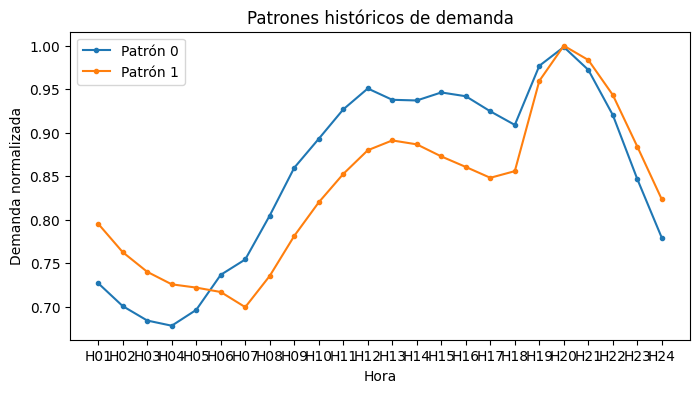

In [6]:
# Dos patrones maximizan la silueta y mantienen una interpretación visible para este primer ejercicio.

kmeans = KMeans(n_clusters=2, n_init=10, random_state=0).fit(train_profiles)
train_patterns = kmeans.labels_
test_patterns = kmeans.predict(test_profiles)

plt.figure(figsize=(8, 4))
for cluster, profile in enumerate(kmeans.cluster_centers_):
    plt.plot(hour_columns, profile, marker=".", label=f"Patrón {cluster}")
plt.xlabel("Hora")
plt.ylabel("Demanda normalizada")
plt.title("Patrones históricos de demanda")
plt.legend()
plt.savefig("../submission/demanda-comercial-perfiles.png", bbox_inches="tight")
plt.show()

In [7]:
# Las primeras seis horas se normalizan con su propio máximo para evitar usar el resto del día al crear predictores.

early_hours = hour_columns[:6]

def build_early_features(daily_data):
    early_demand = daily_data[early_hours]
    return early_demand.div(early_demand.max(axis=1), axis=0)

X_train = build_early_features(train_data)
X_test = build_early_features(test_data)
X_train.head()

,H01,H02,H03,H04,H05,H06
Fecha,,,,,,
2017-01-01,1.0,0.966629,0.937346,0.909341,0.884981,0.868303
2017-01-02,1.0,0.964627,0.942694,0.929127,0.944569,0.978633
2017-01-03,1.0,0.961726,0.935679,0.922923,0.937920,0.971621
2017-01-04,1.0,0.963663,0.934124,0.921861,0.937341,0.977922
2017-01-05,1.0,0.963569,0.938355,0.925458,0.939101,0.973360


In [8]:
# Un clasificador aprende a asociar la forma temprana con el patrón histórico que se completará al final del día.

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pattern_classifier = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=0)),
    ]
)
pattern_classifier.fit(X_train, train_patterns)
predicted_patterns = pattern_classifier.predict(X_test)
predicted_probabilities = pattern_classifier.predict_proba(X_test)

Exactitud en días futuros: 0.980


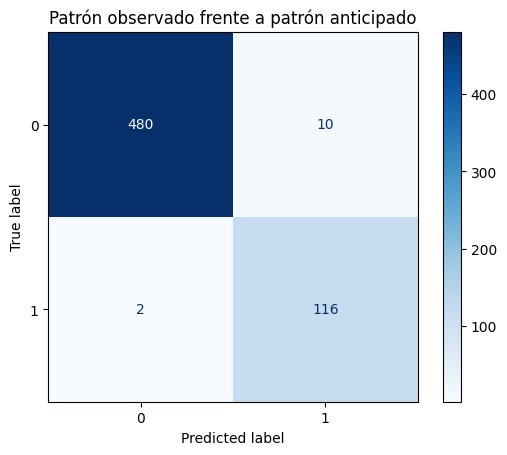

In [9]:
# La evaluación separada muestra qué tan bien las primeras horas anticipan el patrón observado al completar el día.

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

test_accuracy = accuracy_score(test_patterns, predicted_patterns)
print(f"Exactitud en días futuros: {test_accuracy:.3f}")

ConfusionMatrixDisplay.from_predictions(test_patterns, predicted_patterns, cmap="Blues")
plt.title("Patrón observado frente a patrón anticipado")
plt.show()

In [10]:
# La relación con el día de la semana ayuda a interpretar los patrones sin reemplazar la evaluación predictiva.

day_names = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
daily_patterns = pd.DataFrame(
    {
        "Fecha": test_data.index,
        "observed_pattern": test_patterns,
        "predicted_pattern": predicted_patterns,
        "prediction_probability": predicted_probabilities.max(axis=1),
        "day_of_week": pd.Categorical(
            test_data.index.day_of_week.map(dict(enumerate(day_names))),
            categories=day_names,
            ordered=True,
        ),
    }
)
daily_patterns["prediction_probability"] = daily_patterns["prediction_probability"].round(3)
daily_patterns.head()

,Fecha,observed_pattern,predicted_pattern,prediction_probability,day_of_week
0,2021-01-01,1,1,1.000,Viernes
1,2021-01-02,1,1,0.714,Sábado
2,2021-01-03,1,1,0.918,Domingo
3,2021-01-04,0,0,0.997,Lunes
4,2021-01-05,0,0,0.974,Martes


In [11]:
# Se guardan la selección de patrones, las predicciones futuras y un ejemplo reproducible para la auditoría del taller.

import json
import pickle
from pathlib import Path

submission_dir = Path("../submission")
cluster_selection.to_csv(submission_dir / "cluster-selection.csv", index=False)
daily_patterns.to_csv(submission_dir / "demanda-comercial-clusters.csv", index=False)

day_summary = (
    daily_patterns.groupby(["day_of_week", "observed_pattern"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
day_summary.to_csv(submission_dir / "demanda-comercial-dias.csv", index=False)

example = daily_patterns.iloc[[-1]]
example.to_csv(submission_dir / "perfil-recibido.csv", index=False)

with (submission_dir / "pattern_classifier.pkl").open("wb") as file:
    pickle.dump(pattern_classifier, file)

with (submission_dir / "metrics.json").open("w", encoding="utf-8") as file:
    json.dump(
        {
            "cutoff_date": cutoff_date.strftime("%Y-%m-%d"),
            "early_hours": early_hours,
            "test_accuracy": test_accuracy,
        },
        file,
        indent=2,
    )